## Installations

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings 
warnings.filterwarnings("ignore")
import re
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
from itertools import chain
import seaborn as sns
from nltk.util import ngrams
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

## Reading the preprocessed Radiology (MIMIC-IV) Notes data

In [3]:
df_full = pd.read_csv("Preprocessed_radiology_data.csv")
df_full.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,Examination,Indication,Technique,Comparison,Findings,Impression,combined_text,tokenized_text,Gender
0,10000032-RR-14,10000032,22595853.0,RR,14,2180-05-06 21:19:00,2180-05-06 23:32:00,CHEST,with new onset ascites // eval for infection,Chest PA and lateral,None.,"There is no focal consolidation, pleural effus...",No acute cardiopulmonary process.,CHEST with new onset ascites // eval for inf...,"['chest', 'new', 'onset', 'ascites', 'eval', '...",NaN
1,10000032-RR-15,10000032,22595853.0,RR,15,2180-05-06 23:00:00,2180-05-06 23:26:00,LIVER,"year-old female with cirrhosis, jaundice.",Grey scale and color Doppler ultrasound images...,None.,LIVER: The liver is coarsened and nodular in e...,1. Nodular appearance of the liver compatible ...,"LIVER year-old female with cirrhosis, jaundic...","['liver', 'female', 'cirrhosis', 'jaundice', '...",F
2,10000032-RR-16,10000032,22595853.0,RR,16,2180-05-07 09:55:00,2180-05-07 11:15:00,NaN,"HCV cirrhosis c/b ascites, hiv on ART, h/o IV...",Ultrasound guided diagnostic and therapeutic p...,Abdominal ultrasound,Limited grayscale ultrasound imaging of the ab...,Successful uncomplicated ultrasound guided dia...,"nan HCV cirrhosis c/b ascites, hiv on ART, h/...","['hcv', 'cirrhosis', 'c', 'b', 'ascites', 'hiv...",NaN
3,10000032-RR-18,10000032,NaN,RR,18,2180-06-03 12:46:00,2180-06-03 14:01:00,Ultrasound,"year old woman with cirrhosis, ascites despit...",Ultrasound guided therapeutic paracentesis,.,Limited grayscale ultrasound imaging of the ab...,Uneventful therapeutic paracentesis yielding 1...,"Ultrasound year old woman with cirrhosis, asc...","['ultrasound', 'woman', 'cirrhosis', 'ascites'...",F
4,10000032-RR-20,10000032,NaN,RR,20,2180-07-08 13:18:00,2180-07-08 14:15:00,Paracentesis,"year old woman with cirrhosis, ascites despit...",Ultrasound guided therapeutic paracentesis,Paracentesis on,Limited grayscale ultrasound imaging of the ab...,"4.75 L of slightly cloudy, blood tinged fluid ...","Paracentesis year old woman with cirrhosis, a...","['paracentesis', 'woman', 'cirrhosis', 'ascite...",F


In [4]:
df_full.shape

(2321355, 16)

In [5]:
df_full.columns

Index(['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq',
       'charttime', 'storetime', 'Examination', 'Indication', 'Technique',
       'Comparison', 'Findings', 'Impression', 'combined_text',
       'tokenized_text', 'Gender'],
      dtype='object')

In [6]:
df_full['subject_id'].nunique()

237427

## Random Sampling the data

In [7]:
# getting the unique set of patient ids
unique_patients = df_full.drop_duplicates(subset='subject_id')

# sampling 100k patients
sampled_subjects = unique_patients.sample(n=100000, random_state=5230)

# getting other columns 
df = df_full[df_full['subject_id'].isin(sampled_subjects['subject_id'])]
df = df.drop_duplicates(subset='subject_id')
df.shape

(100000, 16)

# Exploratory Data Analysis

# Creating a word cloud of the medical notes

In [8]:
!pip install wordcloud

In [9]:
# removing meanningless words such as nan, old, year
df['combined_text_clean'] = df['combined_text'].str.replace(r'\bnan\b', '', regex=True)
df['combined_text_clean'] = df['combined_text_clean'].str.replace(r'\byear\b', '', regex=True)
df['combined_text_clean'] = df['combined_text_clean'].str.replace(r'\bold\b', '', regex=True)

# removing gender based words
df['combined_text_clean'] = df['combined_text_clean'].str.replace(r'\bwoman\b', '', regex=True)
df['combined_text_clean'] = df['combined_text_clean'].str.replace(r'\bman\b', '', regex=True)

df.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,Examination,Indication,Technique,Comparison,Findings,Impression,combined_text,tokenized_text,Gender,combined_text_clean
24,10000084-RR-12,10000084,NaN,RR,12,2160-11-20 22:39:00,2160-11-20 22:50:00,CHEST,History: with weakness// ?PNA,Chest PA and lateral,None.,Heart size is mildly enlarged. The mediastina...,Mild atelectasis in the lung bases without foc...,CHEST History: with weakness// ?PNA Chest PA ...,"['chest', 'history', 'weakness', 'pna', 'chest...",NaN,CHEST History: with weakness// ?PNA Chest PA ...
30,10000117-RR-10,10000117,NaN,RR,10,2175-05-10 10:12:00,2175-05-11 10:37:00,NaN,NaN,NaN,NaN,NaN,No evidence of malignancy. BI-RADS 1-negative...,nan nan nan nan nan No evidence of malignancy....,"['evidence', 'malignancy', 'bi', 'rads', '1', ...",NaN,No evidence of malignancy. BI-RADS 1-neg...
49,10000285-RR-10,10000285,NaN,RR,10,2161-11-08 18:05:00,2161-11-08 19:06:00,CT,"with severe generalized abd pain, tender most...",Single phase contrast: MDCT axial images were ...,None.,LOWER CHEST: Visualized lung fields are within...,No acute intra-abdominal or intrapelvic abnorm...,"CT with severe generalized abd pain, tender m...","['ct', 'severe', 'generalized', 'abd', 'pain',...",NaN,"CT with severe generalized abd pain, tender m..."
54,10000594-RR-21,10000594,NaN,RR,21,2132-04-16 05:53:00,2132-04-16 10:09:00,NaN,NaN,MDCT-acquired axial images from the lung base...,None available in the system.,NaN,No acute traumatic pathology within the abdome...,nan nan MDCT-acquired axial images from the l...,"['mdct', 'acquired', 'axial', 'images', 'lung'...",NaN,MDCT-acquired axial images from the lung ba...
55,10000635-RR-13,10000635,NaN,RR,13,2138-01-23 08:15:00,2138-01-23 09:38:00,KNEE,year old woman with bilateral knee pain. // ...,NaN,NaN,NaN,"On the right, there is a total knee arthroplas...",KNEE year old woman with bilateral knee pain....,"['knee', 'woman', 'bilateral', 'knee', 'pain',...",F,KNEE with bilateral knee pain. // eval bi...


In [10]:
def generate_wordcloud(df, column): 
    
    # combining the text from the impressions column
    text = " ".join(df[column].astype(str))

    # creating a word cloud 
    wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(text)

    # plotting the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")  
    plt.show()

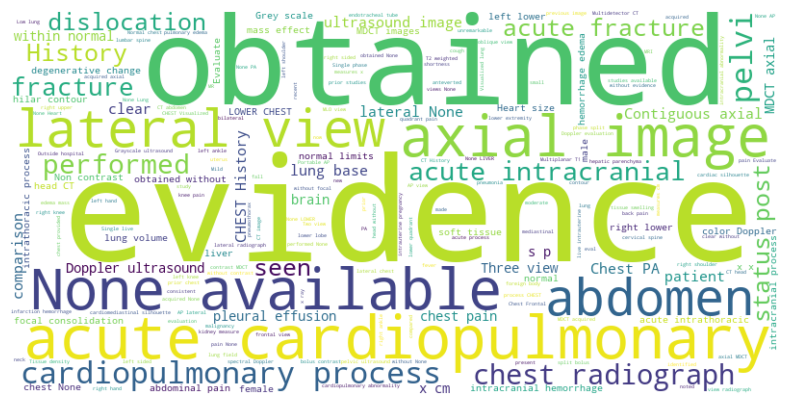

In [11]:
# generate a word cloud of the notes 
generate_wordcloud(df, "combined_text_clean") 

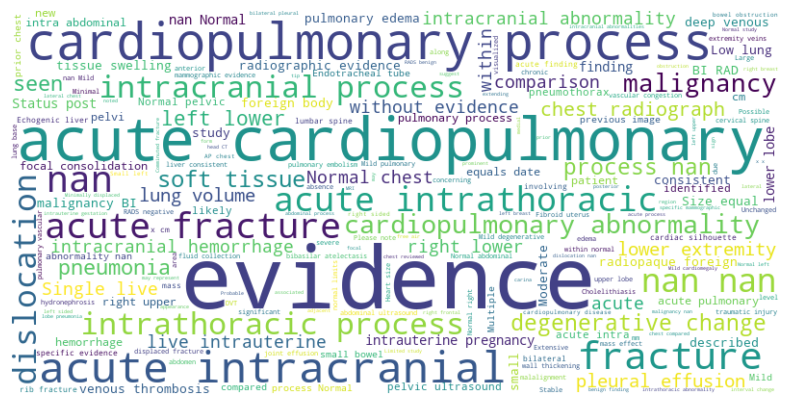

In [12]:
# generate a word cloud of the impressions
generate_wordcloud(df, "Impression") 

# n-gram analysis

In [13]:
# Ensure nltk punkt tokenizer is available
nltk.download("punkt")

# Tokenization function with cleaning
def clean_and_tokenize(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    tokens = word_tokenize(text)  # Tokenize
    tokens = [word for word in tokens if len(word) > 1]  # Remove single chars
    return tokens

df["tokenized_text"] = df["tokenized_text"].apply(clean_and_tokenize)
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Varshni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,Examination,Indication,Technique,Comparison,Findings,Impression,combined_text,tokenized_text,Gender,combined_text_clean
24,10000084-RR-12,10000084,NaN,RR,12,2160-11-20 22:39:00,2160-11-20 22:50:00,CHEST,History: with weakness// ?PNA,Chest PA and lateral,None.,Heart size is mildly enlarged. The mediastina...,Mild atelectasis in the lung bases without foc...,CHEST History: with weakness// ?PNA Chest PA ...,"[chest, history, weakness, pna, chest, pa, lat...",NaN,CHEST History: with weakness// ?PNA Chest PA ...
30,10000117-RR-10,10000117,NaN,RR,10,2175-05-10 10:12:00,2175-05-11 10:37:00,NaN,NaN,NaN,NaN,NaN,No evidence of malignancy. BI-RADS 1-negative...,nan nan nan nan nan No evidence of malignancy....,"[evidence, malignancy, bi, rads, negative, rou...",NaN,No evidence of malignancy. BI-RADS 1-neg...
49,10000285-RR-10,10000285,NaN,RR,10,2161-11-08 18:05:00,2161-11-08 19:06:00,CT,"with severe generalized abd pain, tender most...",Single phase contrast: MDCT axial images were ...,None.,LOWER CHEST: Visualized lung fields are within...,No acute intra-abdominal or intrapelvic abnorm...,"CT with severe generalized abd pain, tender m...","[ct, severe, generalized, abd, pain, tender, s...",NaN,"CT with severe generalized abd pain, tender m..."
54,10000594-RR-21,10000594,NaN,RR,21,2132-04-16 05:53:00,2132-04-16 10:09:00,NaN,NaN,MDCT-acquired axial images from the lung base...,None available in the system.,NaN,No acute traumatic pathology within the abdome...,nan nan MDCT-acquired axial images from the l...,"[mdct, acquired, axial, images, lung, bases, p...",NaN,MDCT-acquired axial images from the lung ba...
55,10000635-RR-13,10000635,NaN,RR,13,2138-01-23 08:15:00,2138-01-23 09:38:00,KNEE,year old woman with bilateral knee pain. // ...,NaN,NaN,NaN,"On the right, there is a total knee arthroplas...",KNEE year old woman with bilateral knee pain....,"[knee, woman, bilateral, knee, pain, eval, bil...",F,KNEE with bilateral knee pain. // eval bi...


In [14]:
# flattening the tokenized text
all_tokens = list(chain.from_iterable(df["tokenized_text"]))

# defining a function to generate top N n-grams
def get_top_ngrams(tokens, n=2, top_k=15):
    n_grams = list(ngrams(tokens, n))  # Generate n-grams
    n_grams_freq = Counter(n_grams)    # Count occurrences
    return n_grams_freq.most_common(top_k)

# extracting the top unigrams, bigrams, trigrams
top_unigrams = get_top_ngrams(all_tokens, n=1)
top_bigrams = get_top_ngrams(all_tokens, n=2)
top_trigrams = get_top_ngrams(all_tokens, n=3)

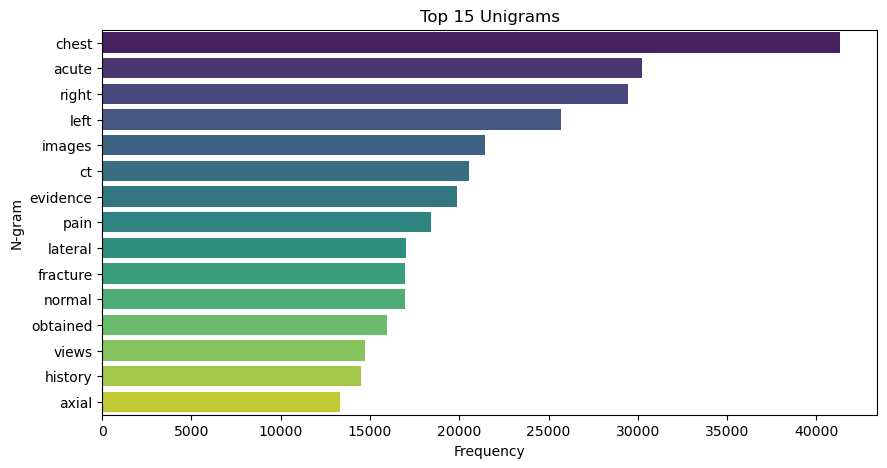

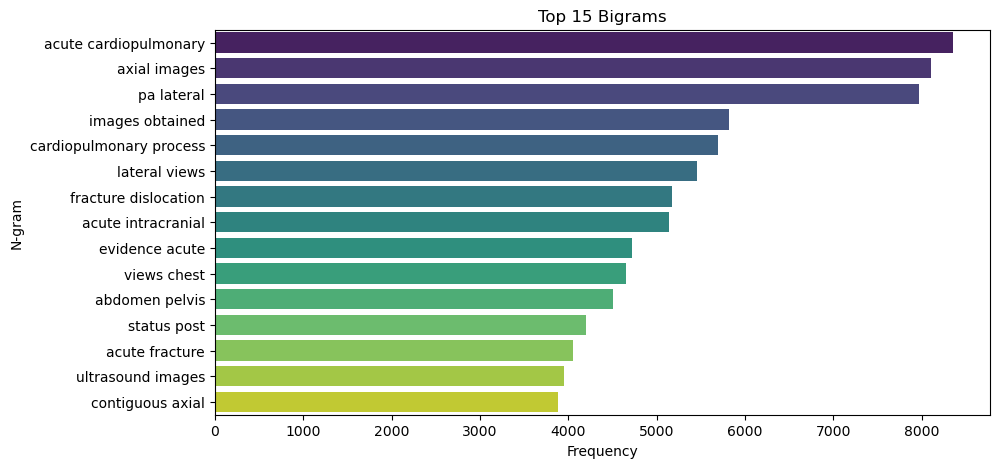

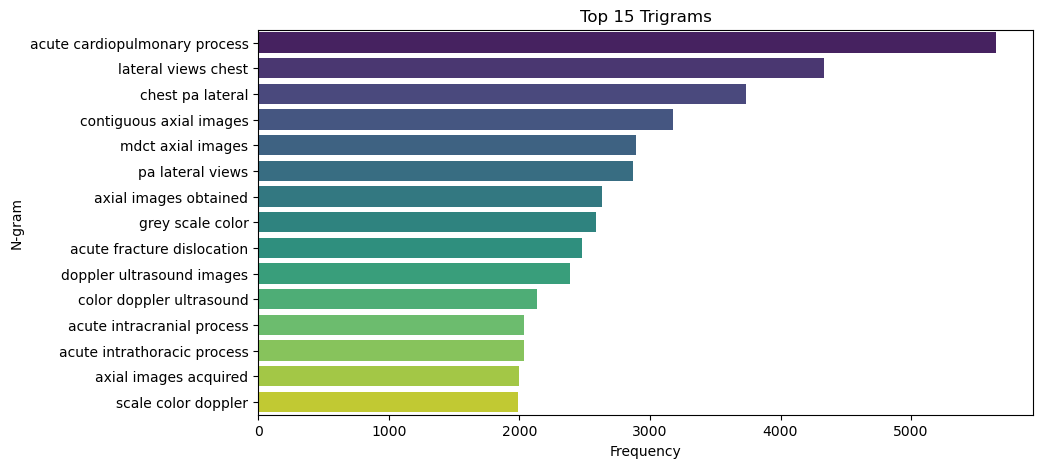

In [15]:
# Convert to DataFrame for visualization
def plot_ngrams(ngrams_freq, title):
    ngrams_df = pd.DataFrame(ngrams_freq, columns=["N-gram", "Frequency"])
    ngrams_df["N-gram"] = ngrams_df["N-gram"].apply(lambda x: " ".join(x))  # Convert tuple to string
    
    plt.figure(figsize=(10, 5))
    sns.barplot(y="N-gram", x="Frequency", data=ngrams_df, palette="viridis")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

# plotting the results 
plot_ngrams(top_unigrams, "Top 15 Unigrams")
plot_ngrams(top_bigrams, "Top 15 Bigrams")
plot_ngrams(top_trigrams, "Top 15 Trigrams")

## Gender Distribution

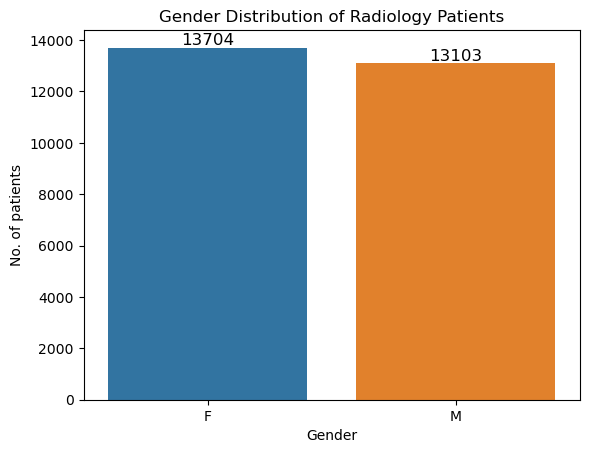

In [16]:
# plotting the distribution
ax = sns.countplot(x =df['Gender']) 

# annotating each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')
# adding title and labels
plt.title("Gender Distribution of Radiology Patients")
plt.xlabel("Gender")
plt.ylabel("No. of patients")

plt.show()

### About 73% of the patients have not been assigned a gender, the remaining has an equal proportion of male and female patients 

## Using Meta Llama embeddings to get risk labels

In [17]:
!pip install llama-index
!pip install sentence-transformers

## Using Llama Sentence Transformers to get the embeddings

In [18]:
from sentence_transformers import SentenceTransformer

# loading the pre-trained model
model = SentenceTransformer("all-MiniLM-L6-v2")

# converting to list
texts = df['tokenized_text'].astype(str).tolist()

# getting the embeddings
embeddings = model.encode(texts, show_progress_bar=True)

# converting the embeddings to numpy array
embeddings = np.array(embeddings)
embeddings

Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

array([[ 0.07213303,  0.00686995,  0.02586493, ...,  0.08086822,
        -0.00780626,  0.0681905 ],
       [-0.01781616,  0.05320481, -0.05997583, ...,  0.05472964,
         0.02374395,  0.03159907],
       [ 0.06052114, -0.04511177,  0.00223457, ...,  0.07483384,
         0.0199872 ,  0.01300492],
       ...,
       [ 0.00198195,  0.06177508, -0.02314403, ...,  0.06997048,
        -0.01130462,  0.05170258],
       [ 0.01814183, -0.05978   ,  0.04780623, ...,  0.1168035 ,
         0.03732456,  0.0152648 ],
       [ 0.07533486, -0.02853974,  0.02408571, ...,  0.16481555,
         0.01037208,  0.0399985 ]], dtype=float32)

## Using K-means to cluster the Llama embeddings into three risk levels - High, Medium and Low

In [19]:
# definings 3 clusters for High, Medium, Low
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# mapping cluster labels to get the 3 categories
cluster_centers = kmeans.cluster_centers_
magnitudes = np.linalg.norm(cluster_centers, axis=1)
ordered_indices = np.argsort(magnitudes)

# lowest norm = 'Low', middle = 'Medium', highest = 'High'
cluster_to_risk = {}
cluster_to_risk[ordered_indices[0]] = "Low"
cluster_to_risk[ordered_indices[1]] = "Medium"
cluster_to_risk[ordered_indices[2]] = "High"

# applying above mapping
risk_labels = [cluster_to_risk[label] for label in cluster_labels]

# adding the risk label to the dataframe
df["risk_label"] = risk_labels
df.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,Examination,Indication,Technique,Comparison,Findings,Impression,combined_text,tokenized_text,Gender,combined_text_clean,risk_label
24,10000084-RR-12,10000084,NaN,RR,12,2160-11-20 22:39:00,2160-11-20 22:50:00,CHEST,History: with weakness// ?PNA,Chest PA and lateral,None.,Heart size is mildly enlarged. The mediastina...,Mild atelectasis in the lung bases without foc...,CHEST History: with weakness// ?PNA Chest PA ...,"[chest, history, weakness, pna, chest, pa, lat...",NaN,CHEST History: with weakness// ?PNA Chest PA ...,Medium
30,10000117-RR-10,10000117,NaN,RR,10,2175-05-10 10:12:00,2175-05-11 10:37:00,NaN,NaN,NaN,NaN,NaN,No evidence of malignancy. BI-RADS 1-negative...,nan nan nan nan nan No evidence of malignancy....,"[evidence, malignancy, bi, rads, negative, rou...",NaN,No evidence of malignancy. BI-RADS 1-neg...,Low
49,10000285-RR-10,10000285,NaN,RR,10,2161-11-08 18:05:00,2161-11-08 19:06:00,CT,"with severe generalized abd pain, tender most...",Single phase contrast: MDCT axial images were ...,None.,LOWER CHEST: Visualized lung fields are within...,No acute intra-abdominal or intrapelvic abnorm...,"CT with severe generalized abd pain, tender m...","[ct, severe, generalized, abd, pain, tender, s...",NaN,"CT with severe generalized abd pain, tender m...",Low
54,10000594-RR-21,10000594,NaN,RR,21,2132-04-16 05:53:00,2132-04-16 10:09:00,NaN,NaN,MDCT-acquired axial images from the lung base...,None available in the system.,NaN,No acute traumatic pathology within the abdome...,nan nan MDCT-acquired axial images from the l...,"[mdct, acquired, axial, images, lung, bases, p...",NaN,MDCT-acquired axial images from the lung ba...,Low
55,10000635-RR-13,10000635,NaN,RR,13,2138-01-23 08:15:00,2138-01-23 09:38:00,KNEE,year old woman with bilateral knee pain. // ...,NaN,NaN,NaN,"On the right, there is a total knee arthroplas...",KNEE year old woman with bilateral knee pain....,"[knee, woman, bilateral, knee, pain, eval, bil...",F,KNEE with bilateral knee pain. // eval bi...,Low


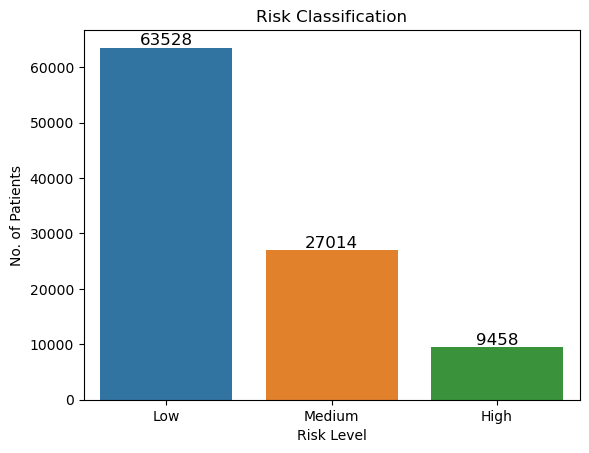

In [20]:
# Sorting the labels in descending order
sorted_order = df['risk_label'].value_counts().sort_values(ascending=False).index

# creating a count plot
ax = sns.countplot(x='risk_label', data=df, order=sorted_order)

# adding title and labels
plt.title("Risk Classification")
plt.xlabel("Risk Level")
plt.ylabel("No. of Patients")

# annotating each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

## The risk levels obtained from the embeddings shall be considered the truth to train models

## Baseline Keyword-based Model Building 

In [21]:
# Define risk categories
HIGH_RISK_KEYWORDS = {"acute", "fracture", "intracranial", "pulmonary embolism", "malignancy", "pneumonia", "pleural effusion"}
MEDIUM_RISK_KEYWORDS = {"degenerative change", "comparison", "cardiopulmonary process", "edema", "dislocation"}
LOW_RISK_KEYWORDS = {"unchanged", "mild", "stable", "without evidence"}

def classify_risk(notes):
    if any(word in notes for word in HIGH_RISK_KEYWORDS):
        return "High"
    elif any(word in notes for word in MEDIUM_RISK_KEYWORDS):
        return "Medium"
    elif any(word in notes for word in LOW_RISK_KEYWORDS):
        return "Low"
    else:
        return "Unknown"

In [23]:
# Apply risk classification
df["risk_level_baseline"] = df["combined_text_clean"].apply(classify_risk)

# Show distribution of risk levels
print(df["risk_level_baseline"].value_counts())

risk_level_baseline
Unknown    49517
High       40774
Medium      6368
Low         3341
Name: count, dtype: int64


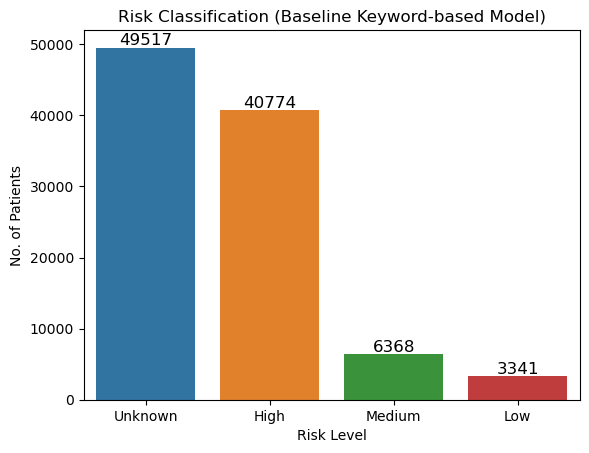

In [24]:
# Sorting the labels in descending order
sorted_order = df['risk_level_baseline'].value_counts().sort_values(ascending=False).index

# creating a count plot
ax = sns.countplot(x='risk_level_baseline', data=df, order=sorted_order)

# adding title and labels
plt.title("Risk Classification (Baseline Keyword-based Model)")
plt.xlabel("Risk Level")
plt.ylabel("No. of Patients")

# annotating each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

## The risk level of 49.5% of the patients is unknown according to the baseline model

In [25]:
# getting the accuarcy
accuracy = accuracy_score(df['risk_label'], df['risk_level_baseline'])

print(f"Baseline Model Accuracy: {accuracy:.4f}")

Baseline Model Accuracy: 0.0407


## Within the ~50% of the patients whose risk level has been assigned, the accuracy of the baseline model is only 4.07%

## Feature Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns_to_encode = ['note_type', 'Gender', 'risk_label']

for column in columns_to_encode: 
    df[column] = le.fit_transform(df[column])

df.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,Examination,Indication,Technique,Comparison,Findings,Impression,combined_text,tokenized_text,Gender,combined_text_clean,risk_label,risk_level_baseline
24,10000084-RR-12,10000084,NaN,1,12,2160-11-20 22:39:00,2160-11-20 22:50:00,CHEST,History: with weakness// ?PNA,Chest PA and lateral,None.,Heart size is mildly enlarged. The mediastina...,Mild atelectasis in the lung bases without foc...,CHEST History: with weakness// ?PNA Chest PA ...,"[chest, history, weakness, pna, chest, pa, lat...",2,CHEST History: with weakness// ?PNA Chest PA ...,2,Low
30,10000117-RR-10,10000117,NaN,1,10,2175-05-10 10:12:00,2175-05-11 10:37:00,NaN,NaN,NaN,NaN,NaN,No evidence of malignancy. BI-RADS 1-negative...,nan nan nan nan nan No evidence of malignancy....,"[evidence, malignancy, bi, rads, negative, rou...",2,No evidence of malignancy. BI-RADS 1-neg...,1,High
49,10000285-RR-10,10000285,NaN,1,10,2161-11-08 18:05:00,2161-11-08 19:06:00,CT,"with severe generalized abd pain, tender most...",Single phase contrast: MDCT axial images were ...,None.,LOWER CHEST: Visualized lung fields are within...,No acute intra-abdominal or intrapelvic abnorm...,"CT with severe generalized abd pain, tender m...","[ct, severe, generalized, abd, pain, tender, s...",2,"CT with severe generalized abd pain, tender m...",1,High
54,10000594-RR-21,10000594,NaN,1,21,2132-04-16 05:53:00,2132-04-16 10:09:00,NaN,NaN,MDCT-acquired axial images from the lung base...,None available in the system.,NaN,No acute traumatic pathology within the abdome...,nan nan MDCT-acquired axial images from the l...,"[mdct, acquired, axial, images, lung, bases, p...",2,MDCT-acquired axial images from the lung ba...,1,High
55,10000635-RR-13,10000635,NaN,1,13,2138-01-23 08:15:00,2138-01-23 09:38:00,KNEE,year old woman with bilateral knee pain. // ...,NaN,NaN,NaN,"On the right, there is a total knee arthroplas...",KNEE year old woman with bilateral knee pain....,"[knee, woman, bilateral, knee, pain, eval, bil...",0,KNEE with bilateral knee pain. // eval bi...,1,Unknown


## Model Building

## Vectorizing the tokenized text using TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)
df['tokenized_text'] = df['tokenized_text'].apply(lambda x: ' '.join(ast.literal_eval(x)) if isinstance(x, str) else ' '.join(x))
text_features = tfidf.fit_transform(df['tokenized_text'].fillna(''))

structured_features = df[['Gender', 'note_type']] 

## We then assign X and y variables for the supervised ML models

### Only the tokenized text of medical notes and categorical features such as Gender (derived) and Note Type are used in the model

### Patient ID, Note ID, HADM ID have not been used in model training owing to confidentiality reasons

In [28]:
import scipy
X = scipy.sparse.hstack((text_features, structured_features.values))
y = df['risk_label']

In [29]:
X.shape

(100000, 502)

In [30]:
y.shape

(100000,)

## We use 80% of the data for training and 20% for testing

In [31]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5230)

In [32]:
X_train.shape

(80000, 502)

In [33]:
y_train.shape

(80000,)

In [34]:
X_test.shape

(20000, 502)

In [35]:
y_test.shape

(20000,)

## We now build supervised machine learning models such as Decision Tree, Random Forest, SVM and XGBoost on the vectorized text

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth = 10, max_features ='sqrt', random_state = 5230),
    "Random Forest": RandomForestClassifier(n_estimators = 100, bootstrap = True, random_state = 5230),
    "SVM": LinearSVC(C = 1, class_weight = "balanced"),  
    "XGBoost": XGBClassifier(n_estimators = 100, max_depth = 10, use_label_encoder = False, eval_metric = 'mlogloss')
}

for name, model in models.items():
    print(f"\n🔹 Training {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Model Accuracy: ", accuracy_score(y_test, y_pred))


🔹 Training Decision Tree
Model Accuracy:  0.8817

🔹 Training Random Forest
Model Accuracy:  0.9645

🔹 Training SVM
Model Accuracy:  0.971

🔹 Training XGBoost
Model Accuracy:  0.9684


## SVM is the best-performing model with an accuracy of 97%

## We check if this can be improved further using Hyperparameter Tuning

In [37]:
from sklearn.model_selection import RandomizedSearchCV

# defining a function for hyperparameter tuning
def tune_model(model, param_grid, X_train, y_train, cv=3, n_iter=10):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='accuracy',
        cv=cv,
        random_state=5230,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    print(f"Best params: {search.best_params_}")
    return search.best_estimator_

# defining models and their parameter grids
model_configs = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=5230),
        "params": {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ['sqrt', 'log2', None]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=5230),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ['sqrt', 'log2'],
            "bootstrap": [True, False]
        }
    },
    "SVM": {
        "model": LinearSVC(),
        "params": {
            "C": [0.1, 1, 10],
            "class_weight": [None, 'balanced']
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=5230),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 6, 10],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "gamma": [0, 1, 5],
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [1, 5, 10]
        }
    }
}


In [38]:
# looping through the models to run hyperparameter tuning
for name, config in model_configs.items():
    print(f"\n🔹 Tuning {name}")
    best_model = tune_model(config['model'], config['params'], X_train, y_train)
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ {name} Test Accuracy: {acc:.4f}")


🔹 Tuning Decision Tree
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 15}
✅ Decision Tree Test Accuracy: 0.9384

🔹 Tuning Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
✅ Random Forest Test Accuracy: 0.9610

🔹 Tuning SVM
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'class_weight': None, 'C': 1}
✅ SVM Test Accuracy: 0.9708

🔹 Tuning XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
✅ XGBoost Test Accuracy: 0.9684


## The model performance of Decision Tree saw a significant jump from ~88% to ~94% with Hyperparameter Tuning

## SVM still stands as the best-performing model with an accuracy of ~97%